# ViT APJN experiments notebook

This notebook follows the `vit-dyt` bootstrap flow from the reference Colab before running the APJN experiments.

In [ ]:
# Optional: install TeX/font packages for publication-style plots.
# Run this cell only if you want the LaTeX/NeurIPS-like font setup below.
!apt-get -qq update
!apt-get -qq install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

In [3]:
# Optional: configure NeurIPS-like LaTeX fonts.
# Run after the apt-get cell above.
# If you want the simpler Times-like fallback instead, use `configure_times_like_tex_fonts()`.
from vit_apjn_notebook_helpers import configure_neurips_like_tex_fonts, configure_times_like_tex_fonts

configure_times_like_tex_fonts()

In [4]:
# Colab/local setup for vit-dyt.
from pathlib import Path
import subprocess
import sys

REPO_DIR = Path('vit-dyt')
INSTALL_TIMM = True
INSTALL_REQUIREMENTS = True
CLONE_IF_MISSING = True

if INSTALL_TIMM:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'timm'], check=True)

if not REPO_DIR.exists() and CLONE_IF_MISSING:
    subprocess.run(['git', 'clone', 'https://github.com/labofdoubt/vit-dyt', str(REPO_DIR)], check=True)

REQ = REPO_DIR / 'requirements.txt'
if INSTALL_REQUIREMENTS and REQ.exists():
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(REQ)], check=True)

if REPO_DIR.exists() and str(REPO_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(REPO_DIR.resolve()))

print('Repo directory:', REPO_DIR.resolve() if REPO_DIR.exists() else 'missing')

Repo directory: /content/vit-dyt


In [5]:
# Common imports and helper bootstrap.
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from vit_apjn_notebook_helpers import *

bootstrap_vit_dyt_repo(
    REPO_DIR,
    clone_if_missing=CLONE_IF_MISSING,
    install_requirements=INSTALL_REQUIREMENTS,
    install_timm=INSTALL_TIMM,
)
set_pub_style()
print('DEVICE =', DEVICE)

DEVICE = cuda


In [6]:
# Global defaults and top-level tuning handles.
DEFAULT_DEPTH = 32
DEFAULT_ALPHAS = tuple(np.arange(0.1, 1.9 + 1e-9, 0.2).astype(float))
DEFAULT_Q0_GRID = tuple(np.linspace(0.0, 2.0, 41))
DEFAULT_P0_GRID = tuple(np.linspace(0.0, 2.0, 41))
DEFAULT_PRELN_SCALE_GRID = tuple(np.linspace(0.4, 8.0, 61))

MODEL_CFG = ModelConfig(
    model_name='vit_base_patch16_224',
    depth=DEFAULT_DEPTH,
    num_classes=100,
    img_size=224,
    replace_gelu_with_relu=True,
    inplace_relu=False,
    seed=0,
)
MEAN_FIELD_CFG = build_mean_field_cfg_for_vit_base(depth=MODEL_CFG.depth)
STYLE_CFG = FinalThreePanelStyleConfig(
    title_fs=18,
    label_fs=18,
    annotation_fs=18,
    colorbar_pad=0.04,
    )

# Direct plotting overrides for notebook figures.
PLOT_TICK_FS = 16
PLOT_LABEL_FS = 18
PLOT_TITLE_FS = 18
PLOT_ANNOTATION_FS = 18
PLOT_ALPHA_LEGEND_FS = 16

EQ_PANEL_WIDTH_RATIOS = (1.0, 1.5, 1.5)
EQ_PANEL_GAP_AB = 0.18
EQ_PANEL_GAP_BC = 0.18

FIT_PANEL_COL_GAP = 0.18
FIT_PANEL_ROW_GAP = 0.22
FIT_LOWER_TO_CBAR_GAP = 0.18
FIT_SCATTER_POINT_ALPHA = 0.55
FIT_PERCENTILE_LABEL_ALPHA = 0.45
FIT_PERCENTILE_LABEL_FS = 11
PANEL_D_REDUCED_GAP = 0.2

print('MODEL_CFG =', cfg_to_dict(MODEL_CFG))

MODEL_CFG = {'model_name': 'vit_base_patch16_224', 'depth': 32, 'num_classes': 100, 'img_size': 224, 'replace_gelu_with_relu': True, 'inplace_relu': False, 'seed': 0}


## 1. Equiangular p-trajectories and APJNs

In [7]:
# Definitions.
EQ_P0 = 0.2
EQ_APJN_LAYERS = tuple(range(0, MODEL_CFG.depth + 1, 4))
EQ_DIRECT_LAYERS = tuple(range(0, MODEL_CFG.depth + 1, 4))

PERM_CFG_EQ = PermTokenConfig(
    batch_size=1,
    q0_init=1.0,
    p0_init=EQ_P0,
    alphas=DEFAULT_ALPHAS,
    perm_start_index=0,
    perm_n_replace=None,
    perm_seed=1235,
    perm_random_rotate=True,
    theory_n_tokens_override=None,
    num_model_inits=1,
)
APJN_CFG_EQ = APJNCifarConfig(
    input_source='equiangular',
    batch_size=1,
    equiangular_q0=1.0,
    equiangular_p0=EQ_P0,
    equiangular_seed=0,
    equiangular_random_rotate=True,
    apjn_layers=EQ_APJN_LAYERS,
    direct_layers=EQ_DIRECT_LAYERS,
    direct_source_block=0,
    alphas=DEFAULT_ALPHAS,
    j_num_draws=10,
    j_normalize_by='Y',
    num_model_inits=1,
)

In [8]:
# Run.
perm_empirical_bundle_eq = run_perm_token_experiment(MODEL_CFG, PERM_CFG_EQ)
perm_theory_bundle_eq = compute_theory_qp_bundle(
    num_layers=MODEL_CFG.depth,
    alphas=DEFAULT_ALPHAS,
    n_tokens=perm_empirical_bundle_eq['n_tokens_ex_cls'],
    q0=1.0,
    p0=EQ_P0,
    mean_field_cfg=MEAN_FIELD_CFG,
)
eq_apjn_bundle = run_cifar_apjn_experiment(MODEL_CFG, APJN_CFG_EQ)

Saved: /content/equiangular_p_inverse_direct_figure.pdf


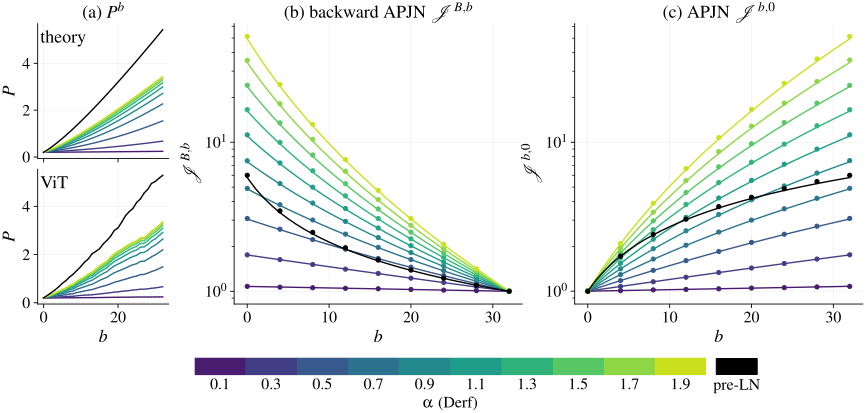

In [9]:
# Plot.
# Tune panel widths with `EQ_PANEL_WIDTH_RATIOS=(wa, wb, wc)`.
# Tune panel gaps with `EQ_PANEL_GAP_AB` and `EQ_PANEL_GAP_BC`.
STYLE_CFG = FinalThreePanelStyleConfig(
    title_fs=18,
    label_fs=18,
    annotation_fs=18,
    colorbar_pad=0.08,
    )

fig_eq = plot_equangular_p_inverse_direct_figure(
    perm_empirical_bundle_eq,
    perm_theory_bundle_eq,
    eq_apjn_bundle,
    STYLE_CFG,
    panel_width_ratios=(1.0, 2.2, 2.2),
    panel_gap_ab=0.5,
    panel_gap_bc=0.4,
    tick_fs=PLOT_TICK_FS,
    label_fs=PLOT_LABEL_FS,
    alpha_legend_fs=PLOT_ALPHA_LEGEND_FS,
    title_fs=PLOT_TITLE_FS,
    annotation_fs=PLOT_ANNOTATION_FS,
)

## 2. Simplified recurrence vs full recurrence

In [10]:
SIMPLIFIED_MIX_ALPHA = 0.5

In [11]:
# Run.
simplified_bundle = prepare_simplified_inverse_comparison(
    eq_apjn_bundle,
    MEAN_FIELD_CFG,
    p0=EQ_P0,
    alpha_for_mix=SIMPLIFIED_MIX_ALPHA,
)

Saved: /content/simplified_inverse_direct_mix_figure.pdf


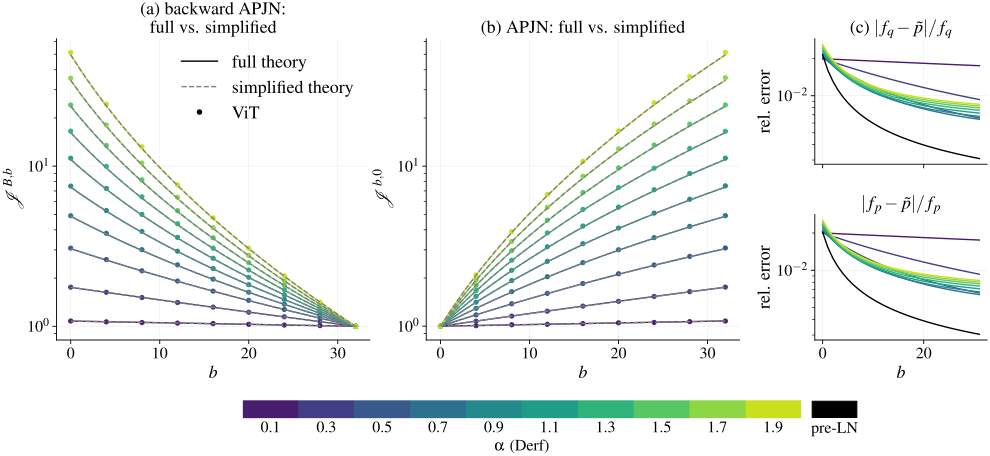

In [12]:
# Plot.
SIMPLIFIED_PANEL_GAP_AB = 0.18
SIMPLIFIED_PANEL_GAP_BC = 0.24
SIMPLIFIED_MIX_HSPACE = 0.4
SIMPLIFIED_ALPHA_CBAR_WIDTH_SCALE = 0.6
SIMPLIFIED_ALPHA_CBAR_HEIGHT_SCALE = 2.0
SIMPLIFIED_LEGEND_ROW_HEIGHT = 0.03

STYLE_CFG = FinalThreePanelStyleConfig(
    colorbar_pad=0.1,
    )

fig_simplified = plot_simplified_inverse_and_mix_figure(
    simplified_bundle,
    STYLE_CFG,
    panel_gap_ab=SIMPLIFIED_PANEL_GAP_AB,
    panel_gap_bc=SIMPLIFIED_PANEL_GAP_BC,
    mix_panel_hspace=SIMPLIFIED_MIX_HSPACE,
    alpha_colorbar_width_scale=SIMPLIFIED_ALPHA_CBAR_WIDTH_SCALE,
    alpha_colorbar_height_scale=SIMPLIFIED_ALPHA_CBAR_HEIGHT_SCALE,
    legend_row_height=SIMPLIFIED_LEGEND_ROW_HEIGHT,
    tick_fs=PLOT_TICK_FS,
    label_fs=PLOT_LABEL_FS,
    alpha_legend_fs=PLOT_ALPHA_LEGEND_FS,
    title_fs=PLOT_TITLE_FS,
    annotation_fs=PLOT_ANNOTATION_FS,
)

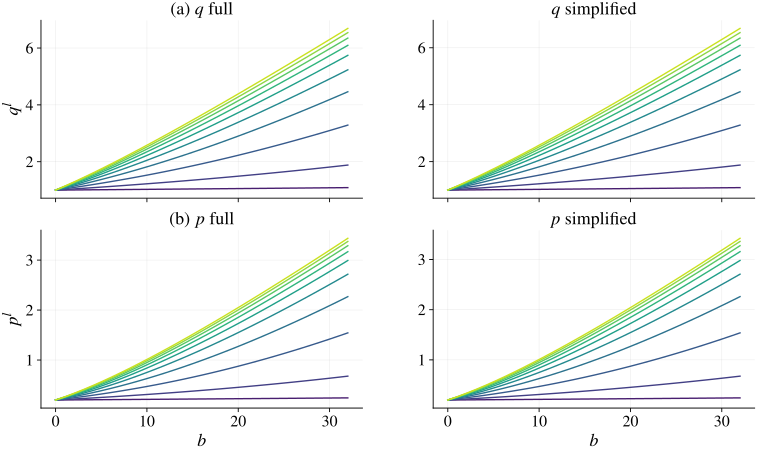

In [12]:
# Plot q/p trajectories from the full and simplified recurrences.
fig_simplified_qp = plot_simplified_qp_comparison_grid(
    simplified_bundle,
    STYLE_CFG,
    tick_fs=PLOT_TICK_FS,
    label_fs=PLOT_LABEL_FS,
    title_fs=PLOT_TITLE_FS,
)

## 3. CIFAR repeated fits and random direct APJN points

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
MODEL_CFG = ModelConfig(
    model_name='vit_base_patch16_224',
    depth=64,
    num_classes=100,
    img_size=224,
    replace_gelu_with_relu=True,
    inplace_relu=False,
    seed=0,
)

In [19]:
# Definitions.
N_SAMPLES = 4
CIFAR_LAYER_STRIDE = 8

RANDOM_DIRECT_LAYERS_PER_SAMPLE = 8
RANDOM_DIRECT_PRELN_WEIGHT = 1.0

RESULTS_POSTFIX = ""
SAVE_RESULTS_ROOT = "/content/drive/MyDrive/ml_projects/mapes_variance"
SAVE_FIT_HIST_RESULTS = True
SAVE_RANDOM_DIRECT_RESULTS = True
REWRITE = False

In [20]:
DEFAULT_Q0_GRID = tuple(np.linspace(0.0, 2.0, 41))
DEFAULT_P0_GRID = tuple(np.linspace(0.0, 2.0, 41))
DEFAULT_PRELN_SCALE_GRID = tuple(np.geomspace(0.2, 80, 400))

In [23]:
# Run repeated fitting.
n_samples = 50
postfix = '80_geomspace'
RESCALE_VIT_PRELN_APJN = False

fit_hist_bundle = run_cifar_fit_histograms(
    MODEL_CFG,
    MEAN_FIELD_CFG,
    alphas=DEFAULT_ALPHAS,
    n_samples=n_samples,
    layer_stride=CIFAR_LAYER_STRIDE,
    batch_seed=666,
    std_threshold=0,
    max_epochs_to_search=20,
    j_num_draws=10,
    q0_values=DEFAULT_Q0_GRID,
    p0_values=DEFAULT_P0_GRID,
    preln_scale_values=DEFAULT_PRELN_SCALE_GRID,
    rescale_vit_preln_apjn=RESCALE_VIT_PRELN_APJN,
    save_results=SAVE_FIT_HIST_RESULTS,
    save_root=SAVE_RESULTS_ROOT,
    rewrite=REWRITE,
    result_postfix=postfix,
)

run_cifar_fit_histograms:   0%|          | 0/50 [00:00<?, ?it/s]

Saved bundle: /content/drive/MyDrive/ml_projects/mapes_variance/fit_hist_depth64_stride8_80_geomspace/results.pkl


In [40]:
N_SAMPLES = 400
RANDOM_DIRECT_PRELN_WEIGHT = 2.0

random_inverse_bundle = run_random_inverse_scatter(
    MODEL_CFG,
    alphas=DEFAULT_ALPHAS,
    n_samples=N_SAMPLES,
    layers_per_sample=RANDOM_DIRECT_LAYERS_PER_SAMPLE,
    batch_seed=20,
    preln_weight=RANDOM_DIRECT_PRELN_WEIGHT,
    scatter_seed=20,
    std_threshold=0,
    max_epochs_to_search=20,
    j_num_draws=10,
    save_results=SAVE_RANDOM_DIRECT_RESULTS,
    save_root=SAVE_RESULTS_ROOT,
    rewrite=REWRITE,
    result_postfix=RESULTS_POSTFIX,
)

run_random_inverse_scatter:   0%|          | 0/400 [00:00<?, ?it/s]

Saved bundle: /content/drive/MyDrive/ml_projects/mapes_variance/random_inverse_depth64_layers8/results.pkl


In [21]:
N_SAMPLES = 400
RANDOM_DIRECT_PRELN_WEIGHT = 2.0
RESCALE_SCATTER_VIT_PRELN_APJN = True
postfix = 'rescaled_preln_weight_2'

random_direct_bundle = run_random_direct_scatter(
    MODEL_CFG,
    alphas=DEFAULT_ALPHAS,
    n_samples=N_SAMPLES,
    layers_per_sample=RANDOM_DIRECT_LAYERS_PER_SAMPLE,
    batch_seed=0,
    preln_weight=RANDOM_DIRECT_PRELN_WEIGHT,
    rescale_vit_preln_apjn=RESCALE_SCATTER_VIT_PRELN_APJN,
    scatter_seed=0,
    std_threshold=0,
    max_epochs_to_search=20,
    j_num_draws=10,
    save_results=SAVE_RANDOM_DIRECT_RESULTS,
    save_root=SAVE_RESULTS_ROOT,
    rewrite=REWRITE,
    result_postfix=postfix,
)

run_random_direct_scatter:   0%|          | 0/400 [00:00<?, ?it/s]

Transform = 
RandomResizedCropAndInterpolation(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bicubic)
RandomHorizontalFlip(p=0.5)
RandAugment(n=2, ops=
	AugmentOp(name=AutoContrast, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=Equalize, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=Invert, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=Rotate, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=PosterizeIncreasing, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=SolarizeIncreasing, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=SolarizeAdd, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=ColorIncreasing, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=ContrastIncreasing, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=BrightnessIncreasing, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=SharpnessIncreasing, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=ShearX, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=ShearY, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=TranslateXRel, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=TranslateYRel, p=0.5, m=9, mstd=0.5))
MaybeToTensor()
Normalize(mean=


  0%|          | 0.00/169M [00:00<?, ?B/s]
  0%|          | 32.8k/169M [00:00<18:15, 154kB/s]
  0%|          | 65.5k/169M [00:00<18:22, 153kB/s]
  0%|          | 98.3k/169M [00:00<18:22, 153kB/s]
  0%|          | 229k/169M [00:00<08:25, 334kB/s] 
  0%|          | 459k/169M [00:01<04:41, 599kB/s]
  1%|          | 918k/169M [00:01<02:29, 1.12MB/s]
  1%|          | 1.84M/169M [00:01<01:17, 2.15MB/s]
  2%|▏         | 3.70M/169M [00:01<00:39, 4.24MB/s]
  4%|▍         | 6.91M/169M [00:01<00:21, 7.54MB/s]
  6%|▌         | 10.1M/169M [00:02<00:16, 9.71MB/s]
  8%|▊         | 13.4M/169M [00:02<00:13, 11.3MB/s]
 10%|▉         | 16.5M/169M [00:02<00:12, 12.3MB/s]
 12%|█▏        | 19.7M/169M [00:02<00:11, 12.9MB/s]
 13%|█▎        | 22.8M/169M [00:03<00:10, 13.3MB/s]
 15%|█▌        | 26.0M/169M [00:03<00:10, 13.7MB/s]
 17%|█▋        | 29.2M/169M [00:03<00:10, 13.9MB/s]
 19%|█▉        | 32.3M/169M [00:03<00:09, 14.0MB/s]
 21%|██        | 35.5M/169M [00:03<00:09, 14.2MB/s]
 23%|██▎       | 38.6M/169M

Number of the class = 100
Saved bundle: /content/drive/MyDrive/ml_projects/mapes_variance/random_direct_depth64_layers8_rescaled_preln_weight_2/results.pkl


Saved: /content/fit_and_scatter_figure.pdf


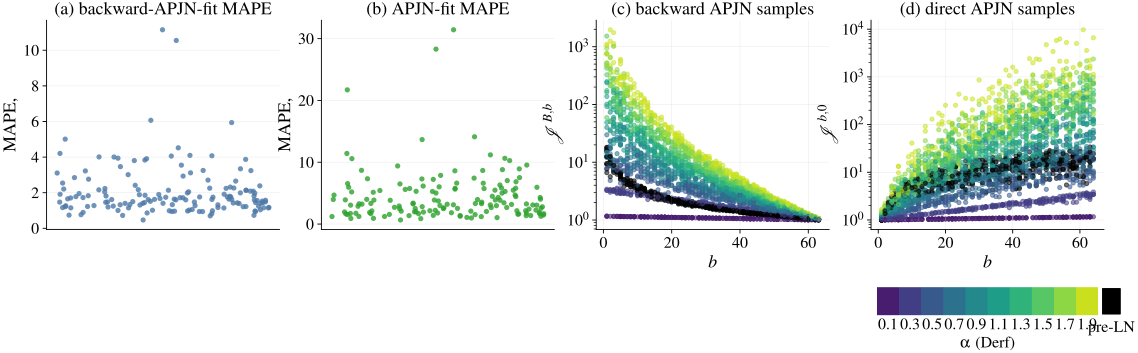

In [24]:
# Plot.
# Load/prepare once, then re-plot from `fit_scatter_plot_data`.
fit_hist_bundle = "/content/drive/MyDrive/ml_projects/mapes_variance/fit_hist_depth64_stride8_80_geomspace/results.pkl"
random_inverse_bundle = "/content/drive/MyDrive/ml_projects/mapes_variance/random_inverse_depth64_layers8/results.pkl"
random_direct_bundle = "/content/drive/MyDrive/ml_projects/mapes_variance/random_direct_depth64_layers8_rescaled_preln_weight_2/results.pkl"

fit_scatter_plot_data = prepare_fit_and_scatter_plot_data(
    fit_hist_bundle,
    random_inverse_bundle,
    random_direct_bundle,
)

fig_hist_scatter = plot_fit_and_scatter_figure(
    fit_scatter_plot_data,
    STYLE_CFG,
    panel_col_gap=FIT_PANEL_COL_GAP,
    panel_row_gap=FIT_PANEL_ROW_GAP,
    lower_row_to_colorbar_gap=FIT_LOWER_TO_CBAR_GAP,
    tick_fs=PLOT_TICK_FS,
    label_fs=PLOT_LABEL_FS,
    alpha_legend_fs=PLOT_ALPHA_LEGEND_FS,
    title_fs=PLOT_TITLE_FS,
    percentile_annotation_fs=FIT_PERCENTILE_LABEL_FS,
    percentile_annotation_alpha=FIT_PERCENTILE_LABEL_ALPHA,
    scatter_point_alpha=FIT_SCATTER_POINT_ALPHA,
)

## 4. Reduced asymptotic direct-APJN figure

In [ ]:
# Definitions.
APJN_CFG_PANEL_D = APJNCifarConfig(
    input_source='cifar',
    batch_size=1,
    cifar_batch_seed=0,
    cifar_batch_draw_index=0,
    cifar_std_threshold=0,
    cifar_max_epochs_to_search=20,
    apjn_layers=tuple(),
    direct_layers=tuple(range(4, MODEL_CFG.depth + 1, 4)),
    direct_source_block=0,
    alphas=DEFAULT_ALPHAS,
    j_num_draws=10,
    j_normalize_by='Y',
    num_model_inits=1,
)

In [ ]:
# Run.
panel_d_cifar_bundle = run_cifar_apjn_experiment(MODEL_CFG, APJN_CFG_PANEL_D)
panel_d_fit_cfg = APJNFitConfig(
    metric='mape',
    q0_values=DEFAULT_Q0_GRID,
    p0_values=DEFAULT_P0_GRID,
    q0_num=len(DEFAULT_Q0_GRID),
    p0_num=len(DEFAULT_P0_GRID),
    separate_panel_d_fits=False,
    preln_scale_values=DEFAULT_PRELN_SCALE_GRID,
    preln_scale_num=len(DEFAULT_PRELN_SCALE_GRID),
    refine_radius=0.2,
)
PANEL_D_CFG_LOCAL = PanelDConfig(
    num_layers=MODEL_CFG.depth,
    q0=1.0,
    p0=0.5,
    n_tokens=int(panel_d_cifar_bundle['seq_len'] - 1),
    sigma_w1=MEAN_FIELD_CFG.sigma_w1,
    sigma_w2=MEAN_FIELD_CFG.sigma_w2,
    sigma_o=MEAN_FIELD_CFG.sigma_o,
    sigma_v=MEAN_FIELD_CFG.sigma_v,
    sigma_a=MEAN_FIELD_CFG.sigma_a,
)
panel_d_direct_fit = fit_panel_d_direct_initial_conditions(
    panel_d_cifar_bundle,
    panel_d_fit_cfg,
    MEAN_FIELD_CFG,
    PANEL_D_CFG_LOCAL,
    DEFAULT_ALPHAS,
)
panel_d_bundle_reduced = build_panel_d_curves(
    PANEL_D_CFG_LOCAL,
    DEFAULT_ALPHAS,
    cifar_panel_bundle=panel_d_cifar_bundle,
    panel_d_fit_bundle=panel_d_direct_fit,
)


In [ ]:
# Plot.
fig_panel_d_reduced = plot_panel_d_reduced_figure(
    panel_d_bundle_reduced,
    DEFAULT_ALPHAS,
    STYLE_CFG,
    panel_gap=PANEL_D_REDUCED_GAP,
    tick_fs=PLOT_TICK_FS,
    label_fs=PLOT_LABEL_FS,
    alpha_legend_fs=PLOT_ALPHA_LEGEND_FS,
    title_fs=PLOT_TITLE_FS,
)